# Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products
### Stochastic Rain Paths

This is the second notebook of the project **"Parametric Rainfall Insurance — Stochastic Loss Simulation for Weather-Linked Products"**

This notebook attempts to simulate stochastic rainfall paths for 366 days. For simulating rainfall each day, we simulate the paths for the mean of the distribution of daily rainfall. This is a discrete stochastic process: $\mu_{t} = \bar{\mu_{t}} + X_{t}$. $\bar{\mu_{t}}$ is the observed average daily rainfall across 22 years data. 

The notebook fits a AR(1) time series to $X_{t}$ and then simulates paths for $\mu_{t}$. Using these $\mu_{t}$ paths, we simulate rainfall on a given day using two approaches:

- **Approach A**: Using the fitted Tweedie distribution on full rainfall data to simulate the rainfall on each day by varying the parameter $\mu$ and keeping other parameters constant (parameters of Tweedie being: $\mu$ as the simulated $\mu_{t}$ paths, power parameter as 1.90, and $\phi$ as fitted from Notebook 01 of this project).  

- **Approach B**: Use the Markov Chain to simulate if it should rain on a particular day given the rainfall status on the previous day. Using this simulated rain status, if it does rain, we simulate a value from the fitted Gamma distribution on non-zero daily rainfall data. This Gamma distribution's $\alpha$ parameter would be fixed and $\beta$ would vary as $\frac{\mu_{t}}{\alpha * \text{ probability that the precipitation is greater than 0}}$. The probability is divided in the denominator because for the gamma distribution, we need the conditional mean but simulated $\mu_{t}$ paths are unconditional.  

We compare both the approaches and discuss limitations of each approach. 

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import datetime
from tweedie import tweedie
import import_ipynb
import importlib
import random
import warnings

In [2]:
#Import other notebooks from the project
rainfall_distribution_notebook = importlib.import_module("01_RainfallDistribution")

In [3]:
#Rainfall Data loaded
rainfall_data_ts = rainfall_distribution_notebook.rainfall_data

In [4]:
#Assumed path for mu_t is:
#mu_t = mu_t\bar + (X_t)
#mu_t - mu_t\bar = X_t
rainfall_data_ts.loc[:, ' Xt'] = rainfall_data_ts[' PRECIPITATION'] - rainfall_data_ts[' AVG_RAINFALL']
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

In [5]:
#Confirm stationarity of the time series using adfuller test
from statsmodels.tsa.stattools import adfuller

result = adfuller(rainfall_data_ts[' Xt'])

if __name__=='__main__':
    print("ADF statistic:", result[0])
    print("p-value:", result[1])

ADF statistic: -74.77464384199979
p-value: 0.0


p-value is 0, the process $X_{t}$ is stationary.

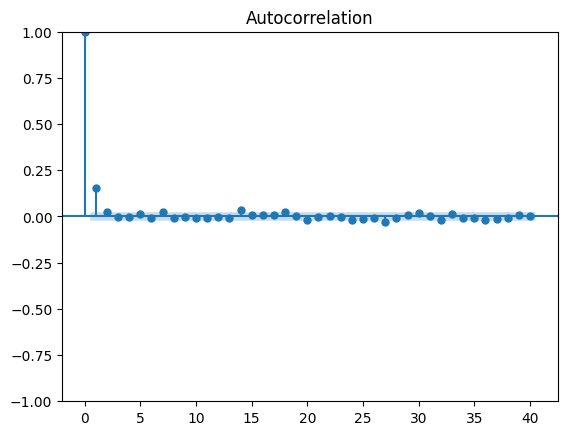

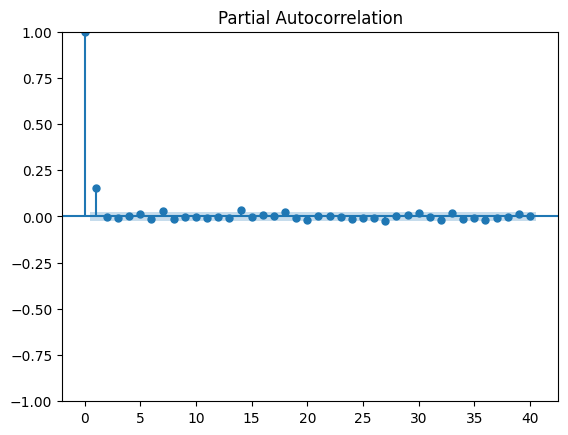

In [6]:
#Plotting ACF and PACF to check which process Xt follows
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
if __name__=='__main__':
    plot_acf(rainfall_data_ts[' Xt'], lags=40)
    plot_pacf(rainfall_data_ts[' Xt'], lags=40)

Both the ACF and PACF display a small spike at lag 1 and negligible autocorrelation beyond that. The similarity between the two functions reflects weak temporal dependence in the residual series rather than indicating a higher-order ARMA process. Given the low magnitude of autocorrelations, a simple AR(1) specification is sufficient to capture the limited persistence present.

In [15]:
#Fitting AR(1) on Xt
from statsmodels.tsa.ar_model import AutoReg
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning

ts = rainfall_data_ts[' Xt']
ts.index = rainfall_data_ts[' DATE']

ar1_model = AutoReg(ts, lags=1).fit()

phi_ar1 = ar1_model.params[1]
sigma_ar1 = np.sqrt(ar1_model.sigma2)

# Suppress statsmodels ValueWarning (no frequency)
warnings.filterwarnings("ignore", category=ValueWarning)

# Suppress pandas FutureWarning (Series indexing)
warnings.filterwarnings("ignore", category=FutureWarning)

In [8]:
#Simulate paths for Xt
#Xt = phi*X_(t-1) + e_t
#The AR(1) process assumes Gaussian innovations for tractability, although rainfall deviations may exhibit non-normal characteristics such as skewness and heavy tails. 
number_of_paths = 1000
number_of_days = 366

Xt_paths = np.zeros((number_of_paths, number_of_days+1))
Xt_paths[:,0]=0 #X_0=0

for i in range(number_of_paths):
    for j in range(1,number_of_days):
        Xt_paths[i,j] = phi_ar1*Xt_paths[i,j-1]+np.random.normal(0,sigma_ar1)
        

In [9]:
#Simulate paths for mu_t
avg_rainfall = np.array(rainfall_data_ts[' AVG_RAINFALL'][:366])

mu_t_paths = np.zeros((number_of_paths, number_of_days))
for i in range(number_of_paths):
    for j in range(number_of_days):
        mu_t_paths[i,j] = np.maximum(avg_rainfall[j]+Xt_paths[i,j+1],1e-6)

In [10]:
#Simulate daily rainfall for the next year
np.random.seed(43)

#Approach A: Simualte rainfall paths using Tweedie
rainfall_amounts_tweedie = tweedie.rvs(
    rainfall_distribution_notebook.p_est,
    mu=mu_t_paths,
    phi=rainfall_distribution_notebook.phi_est,
    size=mu_t_paths.shape
)

#Approach B: Simulate rainfall paths using Occurence-Intensity Framework
p_wet = (rainfall_data_ts[' PRECIPITATION'] > 0).mean()
rainfall_amounts_occ_gamma= np.zeros((number_of_paths, number_of_days))
for i in range(number_of_paths):
    state = np.zeros(number_of_days)
    for j in range(number_of_days):
        # Step 1: Occurrence
        current_state = state[j-1] if j > 0 else 0 #initial state assumed 0
        if current_state == 1:
            p = rainfall_distribution_notebook.markov_chain[0][0]
        else:
            p = rainfall_distribution_notebook.markov_chain[1][0]
        state[j] = 1 if np.random.rand() < p else 0
        # Step 2: Intensity
        #Fix alpha from fitted distirbution and vary beta based on mu_t_paths
        shape_t = rainfall_distribution_notebook.alpha_non_zero_rainfall
        scale_t = (mu_t_paths[i][j])/(shape_t*p_wet)
        #scale_t = (mu_t_paths[i][j]*scaling_factor)/(shape_t)
        if state[j] == 1:
            rainfall_amounts_occ_gamma[i,j] = np.random.gamma(shape_t, scale_t)
        else:
            rainfall = 0

### Evaluation of Approach A (Simulating Tweedie Distributions) and Approach B (Occurrence-Severity Framework)

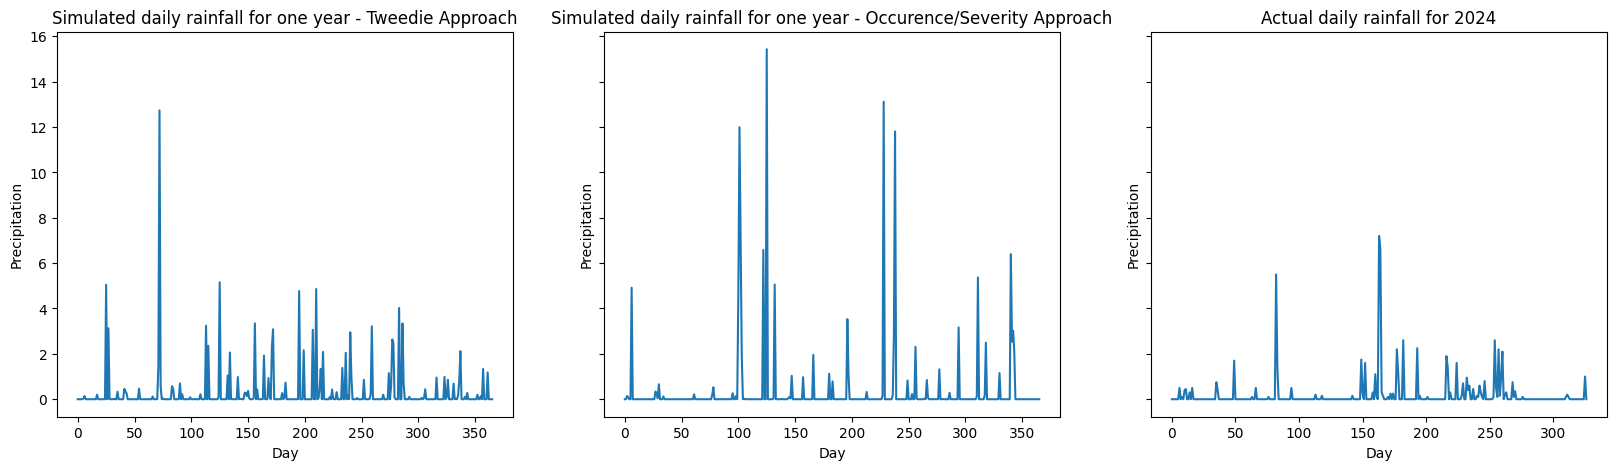

In [21]:
#Plot the simulated rainfall each day for next one year and actual rainfall for the year 2024
if __name__=='__main__':

    fig, axes = plt.subplots(1,3,figsize=(20,5), sharey=True)
    #Plot simulated rainfall for the final simulation - Approach A
    axes[0].plot(rainfall_amounts_tweedie[10])
    axes[0].set_title('Simulated daily rainfall for one year - Tweedie Approach')
    axes[0].set_xlabel('Day')
    axes[0].set_ylabel('Precipitation')
    #Plot simulated rainfall for final simulation - Approach B
    axes[1].plot(rainfall_amounts_occ_gamma[10])
    axes[1].set_title('Simulated daily rainfall for one year - Occurence/Severity Approach')
    axes[1].set_xlabel('Day')
    axes[1].set_ylabel('Precipitation')
    #plot the actual rainfall for the year 2024
    axes[2].plot(rainfall_data_ts[rainfall_data_ts[' YEAR']==2024].reset_index()[' PRECIPITATION'])
    axes[2].set_title('Actual daily rainfall for 2024')
    axes[2].set_xlabel('Day')
    axes[2].set_ylabel('Precipitation')

Both models capture the characteristic spiky structure of Miami's rainfall with long dry periods punctuated by intense rainfall events, broadly resembling the 2024 actual pattern. The Occurrence/Gamma approach produces more clustered extreme spikes particularly around days 120 to 140 and 220 to 240, reflecting the Markov Chain's ability to capture wet day persistence, while Tweedie distributes moderate rainfall events more evenly throughout the year. Peak intensities across both simulated paths and actual 2024 data are comparable at around 13 to 15 units, suggesting both models are reasonably well calibrated to historical rainfall levels.

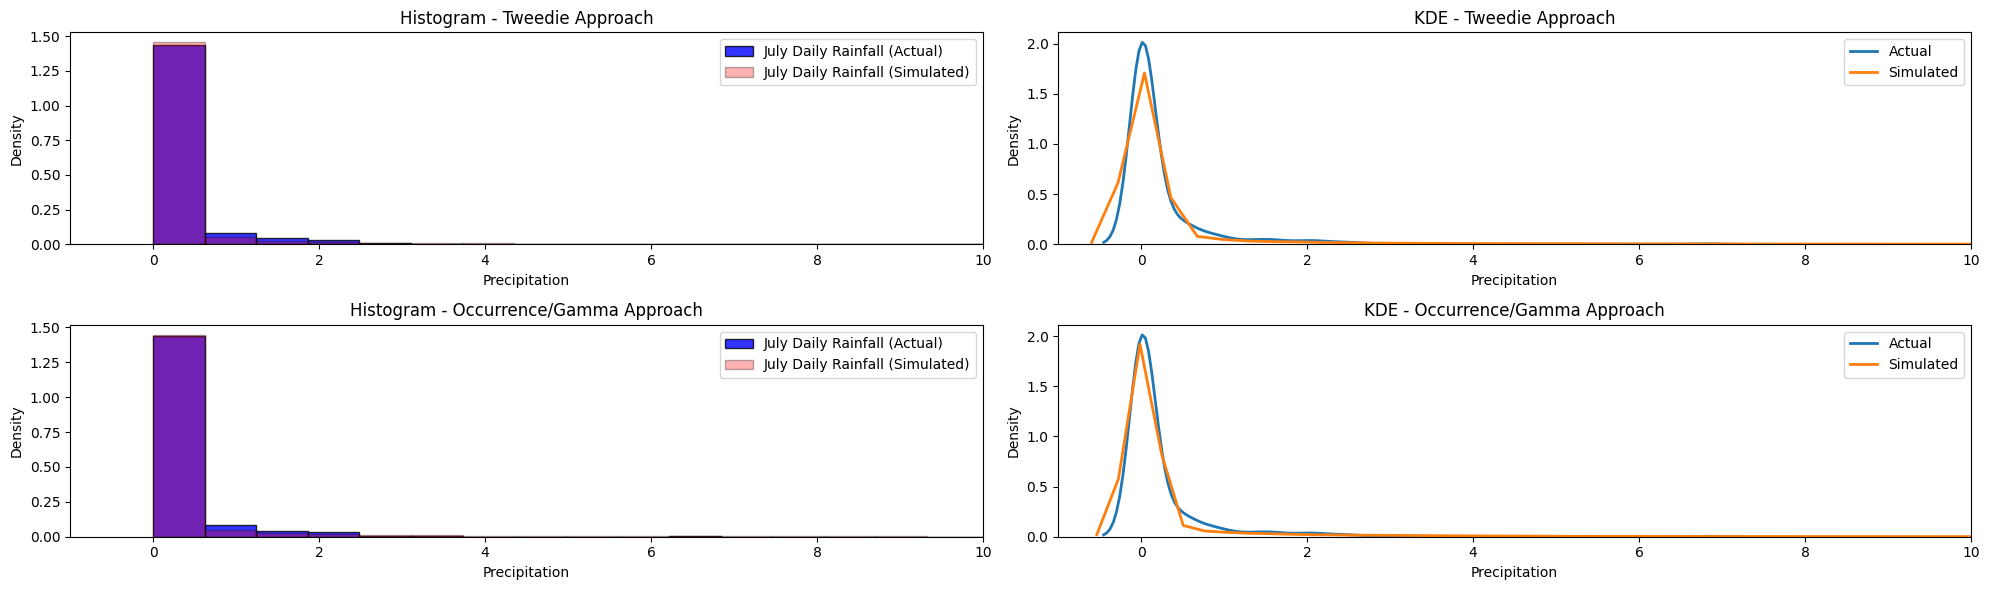

In [12]:
if __name__=='__main__':
    #Distirbution of daily rainfall in July for actual dataset (for)
    simulated_in_july_tweedie = rainfall_amounts_tweedie[:,182:214].flatten()
    simulated_in_july_occ_gamma = rainfall_amounts_occ_gamma[:,182:214].flatten()
    actual_in_july = rainfall_data_ts[rainfall_data_ts[' MONTH']==7][' PRECIPITATION']

    combined_all = np.concatenate([actual_in_july, simulated_in_july_tweedie, simulated_in_july_occ_gamma])
    bins_all = np.histogram_bin_edges(combined_all, bins=100)

    fig, axes = plt.subplots(2, 2, figsize=(20,6))
    #Plot the Histogram - Tweedie
    axes[0,0].hist(actual_in_july, bins=bins_all, density=True, edgecolor='black', label='July Daily Rainfall (Actual)', alpha=0.8, color='b')
    axes[0,0].hist(simulated_in_july_tweedie, bins=bins_all, edgecolor='black', density=True, label='July Daily Rainfall (Simulated)', alpha=0.3, color='r')
    axes[0,0].legend()
    axes[0,0].set_title('Histogram - Tweedie Approach')
    axes[0,0].set_xlabel('Precipitation')
    axes[0,0].set_ylabel('Density')
    #Plot the KDE - Tweedie
    sns.kdeplot(actual_in_july, ax=axes[0,1], label='Actual', linewidth=2)
    sns.kdeplot(simulated_in_july_tweedie, ax=axes[0,1], label='Simulated', linewidth=2)
    axes[0,1].set_title('KDE - Tweedie Approach')
    axes[0,1].set_xlabel('Precipitation')
    axes[0,1].legend()
    
    #Plot the Histogram - Tweedie
    axes[1,0].hist(actual_in_july, bins=bins_all, density=True, edgecolor='black', label='July Daily Rainfall (Actual)', alpha=0.8, color='b')
    axes[1,0].hist(simulated_in_july_occ_gamma, bins=bins_all, edgecolor='black', density=True, label='July Daily Rainfall (Simulated)', alpha=0.3, color='r')
    axes[1,0].legend()
    axes[1,0].set_title('Histogram - Occurrence/Gamma Approach')
    axes[1,0].set_xlabel('Precipitation')
    axes[1,0].set_ylabel('Density')
    #Plot the KDE - Tweedie
    sns.kdeplot(actual_in_july, ax=axes[1,1], label='Actual', linewidth=2)
    sns.kdeplot(simulated_in_july_occ_gamma, ax=axes[1,1], label='Simulated', linewidth=2)
    axes[1,1].set_title('KDE - Occurrence/Gamma Approach')
    axes[1,1].set_xlabel('Precipitation')
    axes[1,1].legend()

    # Apply same xlim to all 4 axes at the end
    for ax in axes.flatten():
        ax.set_xlim(-1, 10)

    plt.tight_layout()
    plt.show()

Both models reproduce the July daily rainfall distribution reasonably well, capturing the dominant concentration of near zero values and the right skewed tail extending to around 3mm. The Tweedie KDE shows a slightly better match to the actual distribution in the bulk region around 0 to 1mm, while the Occurrence/Gamma approach produces a marginally narrower peak suggesting mild underdispersion relative to actual July rainfall. Overall both models perform comparably on this diagnostic with neither showing a clear advantage.

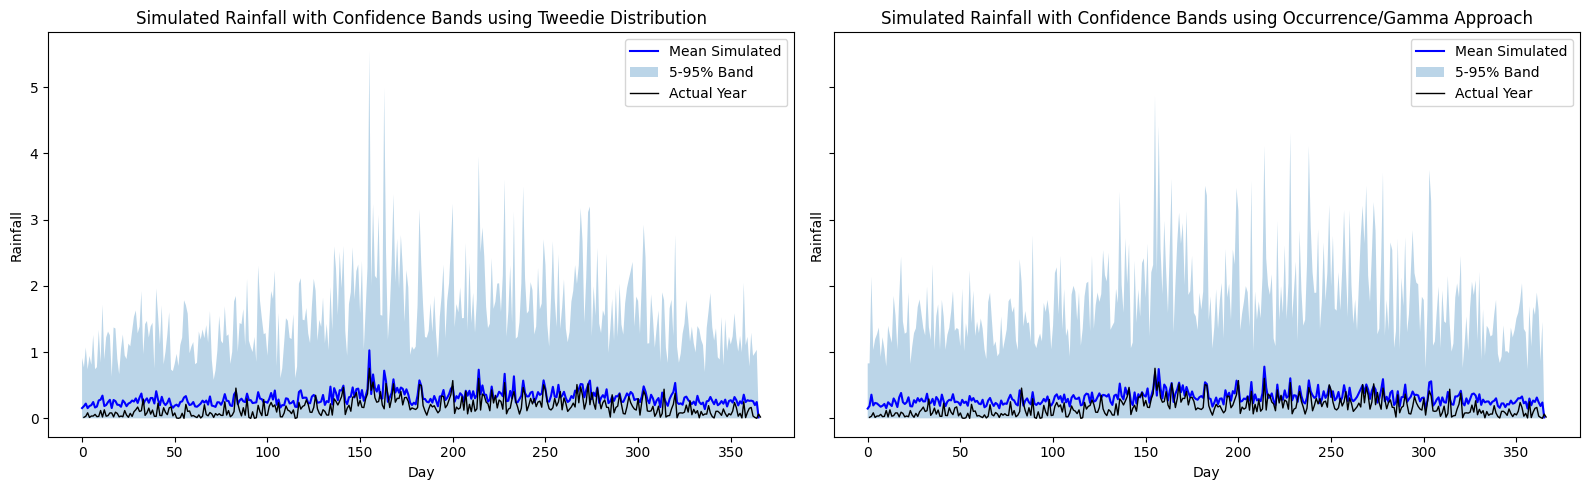

In [23]:
if __name__=='__main__':
    #Plotting the mean simulated and actual rainfalls
    mean_sim_tweedie = rainfall_amounts_tweedie.mean(axis=0)
    p5_tweedie = np.percentile(rainfall_amounts_tweedie, 5, axis=0)
    p95_tweedie = np.percentile(rainfall_amounts_tweedie, 95, axis=0)

    mean_sim_occ_gamma = rainfall_amounts_occ_gamma.mean(axis=0)
    p5_occ_gamma = np.percentile(rainfall_amounts_occ_gamma, 5, axis=0)
    p95_occ_gamma = np.percentile(rainfall_amounts_occ_gamma, 95, axis=0)

    actual_mean = rainfall_data_ts.groupby(' DAY_OF_YEAR')[' PRECIPITATION'].mean()

    fix, axes = plt.subplots(1,2,figsize=(16,5), sharey=True)
    #Plot - Approach A
    axes[0].plot(mean_sim_tweedie, label='Mean Simulated', color='blue')
    axes[0].fill_between(range(len(mean_sim_tweedie)), p5_tweedie, p95_tweedie, alpha=0.3, label='5-95% Band')
    axes[0].plot(actual_mean, label='Actual Year', color='black', linewidth=1)
    axes[0].set_xlabel('Day')
    axes[0].set_ylabel('Rainfall')
    axes[0].set_title('Simulated Rainfall with Confidence Bands using Tweedie Distribution')
    axes[0].legend()
    
    #Plot - Approach B
    axes[1].plot(mean_sim_occ_gamma, label='Mean Simulated', color='blue')
    axes[1].fill_between(range(len(mean_sim_occ_gamma)), p5_occ_gamma, p95_occ_gamma, alpha=0.3, label='5-95% Band')
    axes[1].plot(actual_mean, label='Actual Year', color='black', linewidth=1)
    axes[1].set_xlabel('Day')
    axes[1].set_ylabel('Rainfall')
    axes[1].set_title('Simulated Rainfall with Confidence Bands using Occurrence/Gamma Approach')
    axes[1].legend()
    plt.savefig("images/rainfall_simulation.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

Both models produce comparable confidence bands and mean simulated paths, with the actual 2024 rainfall (black line) falling within the 5 to 95% band throughout the year for both approaches. The simulated mean slightly overestimates actual rainfall particularly in the first half of the year, which is expected given the stochastic nature of the simulation and year to year variability in Miami's rainfall. The Occurrence/Gamma approach shows a slightly wider confidence band around the wet season (days 150 to 250) reflecting the Markov Chain's tendency to generate clustered wet spells, while Tweedie's band is marginally more uniform across the year. Overall both models demonstrate adequate calibration for use in insurance loss simulation.

In [14]:
#Aggregating rainfalls for each month (we use this in final insurance loss simulation notebook)
month_lengths = [31,28,31,30,31,30,31,31,30,31,30,31]

monthly_rainfall_tweedie = []
start = 0

for days in month_lengths:
    monthly_rainfall_tweedie.append(rainfall_amounts_tweedie[:, start:start+days].sum(axis=1))
    start += days

monthly_rainfall_tweedie = np.column_stack(monthly_rainfall_tweedie)

monthly_rainfall_occ_gamma = []
start = 0

for days in month_lengths:
    monthly_rainfall_occ_gamma.append(rainfall_amounts_occ_gamma[:, start:start+days].sum(axis=1))
    start += days

monthly_rainfall_occ_gamma = np.column_stack(monthly_rainfall_occ_gamma)

### End of Notebook